# Annealing simulations

Showcases the `ANNEALINGg.Annealing` module: a time-Trotterized digital quantum ANNEALINGg protocol that interpolates from an easily-preparable **driver** Hamiltonian `H_D` (whose ground state is a chosen many-body reference state) to the real nuclear Hamiltonian `H_T`, and Trotter-simulates `H(s) = (1-s) H_D + s H_T` on a qubit circuit.

This notebook uses only the module's public API (`AnnealingProtocol`, `Annealing_simulation`) - it does not re-derive any physics inline. The exploratory notebook this module was built from, `ANNEALINGg/ANNEALINGg.ipynb`, worked the algorithm out against an older version of this package; that work is preserved there for reference but is not needed to follow this notebook.

Covers both encodings this package supports:
* **fermionic** - Jordan-Wigner + staircase Pauli-exponential Trotter step.
* **HCB** (hard-CORE boson) - both a direct-gate Trotter step (arbitrary qubit-pair connectivity) and a nearest-neighbor **swap-network** Trotter step (hardware-realistic on linear-connectivity devices).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from openfermion.linalg import get_sparse_operator

from CORE.Nucleus import Nucleus
from ANNEALING.Annealing import AnnealingProtocol, Annealing_simulation


## Consistency checks

Two structural checks that don't depend on the ANNEALINGg schedule/step count at all:

1. The qubit-operator (Pauli-sum) target Hamiltonian `H_T_qubit` used to build the circuit, once projected back onto the physical many-body subspace, exactly reproduces `nucleus.H` (the shell-model Hamiltonian already used throughout the rest of this package).
2. The driver Hamiltonian `H_D`'s ground state (in the small many-body basis) is exactly the chosen reference state - by construction, since `H_D` is built from -|E_ref| distributed evenly over the reference state's occupied orbitals/modes.


In [2]:
def h_t_matches_nucleus_h(nucleus_name, shell, encoding):
    nuc = Nucleus(nucleus_name, shell=shell, encoding=encoding)
    protocol = AnnealingProtocol(nuc, ref_state=0, encoding=encoding)

    H_T_full = get_sparse_operator(protocol.H_T_qubit, n_qubits=protocol.n_qubits).toarray()
    basis_dim = nuc.d_H if encoding == "fermionic" else len(nuc.hcb_states)

    projected = np.zeros((basis_dim, basis_dim), dtype=complex)
    for i in range(basis_dim):
        e_i = np.zeros(basis_dim); e_i[i] = 1.0
        full_i = protocol.embed_subspace_vector(e_i)
        for j in range(basis_dim):
            e_j = np.zeros(basis_dim); e_j[j] = 1.0
            full_j = protocol.embed_subspace_vector(e_j)
            projected[i, j] = full_i.conj() @ (H_T_full @ full_j)

    max_diff = np.max(np.abs(projected.real - nuc.H))
    print(f"{nucleus_name} ({encoding}): max|H_T_qubit projected - nucleus.H| = {max_diff:.2e}")
    return max_diff


for encoding in ["fermionic", "HCB"]:
    h_t_matches_nucleus_h("Be6", "p", encoding)


Be6 (fermionic): max|H_T_qubit projected - nucleus.H| = 1.78e-15
Be6 (HCB): max|H_T_qubit projected - nucleus.H| = 2.22e-16


In [3]:
for encoding in ["fermionic", "HCB"]:
    nuc = Nucleus("Be6", shell="p", encoding=encoding)
    protocol = AnnealingProtocol(nuc, ref_state=0, encoding=encoding)
    eigvals = np.linalg.eigvalsh(protocol.H_D_matrix)
    print(f"{encoding}: H_D ground state index = {np.argmin(eigvals)} (ref_state = {protocol.ref_state})")


fermionic: H_D ground state index = 0 (ref_state = 0)
HCB: H_D ground state index = 0 (ref_state = 0)


## Quick start: `Annealing_simulation`

The one-line entry point, mirroring `Methods.py`'s `*_minimization()` functions: builds the nucleus, runs the ANNEALINGg circuit, and returns the result together with the `Nucleus`.


In [4]:
result, nuc = Annealing_simulation("Be6", shell="p", steps=300, dt=0.05, encoding="fermionic")

print(f"Final energy:       {result['energy']:.4f} MeV")
print(f"Exact ground state: {nuc.eig_val[0]:.4f} MeV")
print(f"Fidelity:            {result['fidelity']:.4f}")


[Qibo 0.2.21|INFO|2026-08-11 17:09:57]: Using qibojit (numba) backend on /CPU:0


Final energy:       -2.9124 MeV
Exact ground state: -3.0488 MeV
Fidelity:            0.9822


## Fermionic ANNEALINGg

Compares the classical (small-matrix, exact-unitary) reference evolution against the Trotterized qubit circuit, alongside the instantaneous eigenvalues of `H(s)` at every step.


In [5]:
nucleus_name, shell = "Be6", "p"
steps, dt = 300, 0.05

nuc = Nucleus(nucleus_name, shell=shell, encoding="fermionic")
protocol = AnnealingProtocol(nuc, ref_state=0, encoding="fermionic")

exact = protocol.exact_evolution(steps=steps, dt=dt)
circuit_result = protocol.run(steps=steps, dt=dt)

print(f"Exact-evolution fidelity: {exact['fidelity']:.4f}")
print(f"Circuit fidelity:         {circuit_result['fidelity']:.4f}")
print(f"Circuit final energy:     {circuit_result['energy']:.4f} MeV (exact GS: {nuc.eig_val[0]:.4f} MeV)")


Exact-evolution fidelity: 0.9817
Circuit fidelity:         0.9822
Circuit final energy:     -2.9124 MeV (exact GS: -3.0488 MeV)


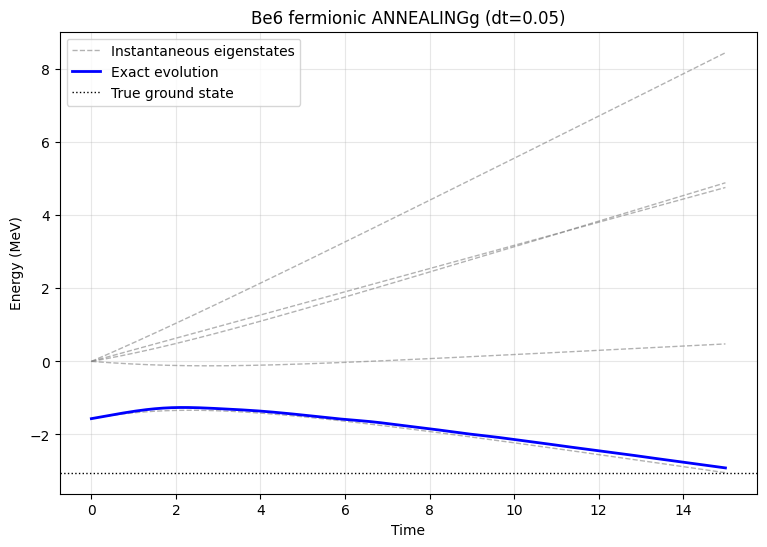

In [6]:
inst = exact["energies_instantaneous"]

plt.figure(figsize=(9, 6))
for i in range(inst.shape[1]):
    plt.plot(exact["time_points"], inst[:, i], "--", color="gray", lw=1, alpha=0.6,
             label="Instantaneous eigenstates" if i == 0 else None)
plt.plot(exact["time_points"], exact["energies_expected"], "b-", lw=2, label="Exact evolution")
plt.axhline(nuc.eig_val[0], color="k", lw=1, ls=":", label="True ground state")
plt.xlabel("Time"); plt.ylabel("Energy (MeV)")
plt.title(f"{nucleus_name} fermionic ANNEALINGg (dt={dt})")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


## HCB ANNEALINGg - direct-gate circuit

Same comparison, HCB (hard-CORE boson) encoding, direct-gate Trotter step (each interaction term applied straight to its own qubit pair, regardless of distance).


In [7]:
nucleus_name, shell = "Be6", "p"
steps, dt = 300, 0.05

nuc = Nucleus(nucleus_name, shell=shell, encoding="HCB")
protocol = AnnealingProtocol(nuc, ref_state=0, encoding="HCB")

exact = protocol.exact_evolution(steps=steps, dt=dt)
circuit_result = protocol.run(steps=steps, dt=dt, swap_network=False)

print(f"Exact-evolution fidelity: {exact['fidelity']:.4f}")
print(f"Circuit fidelity:         {circuit_result['fidelity']:.4f}")
print(f"Circuit final energy:     {circuit_result['energy']:.4f} MeV (exact GS: {nuc.eig_val[0]:.4f} MeV)")


Exact-evolution fidelity: 0.9818
Circuit fidelity:         0.9827
Circuit final energy:     -2.8885 MeV (exact GS: -3.0488 MeV)


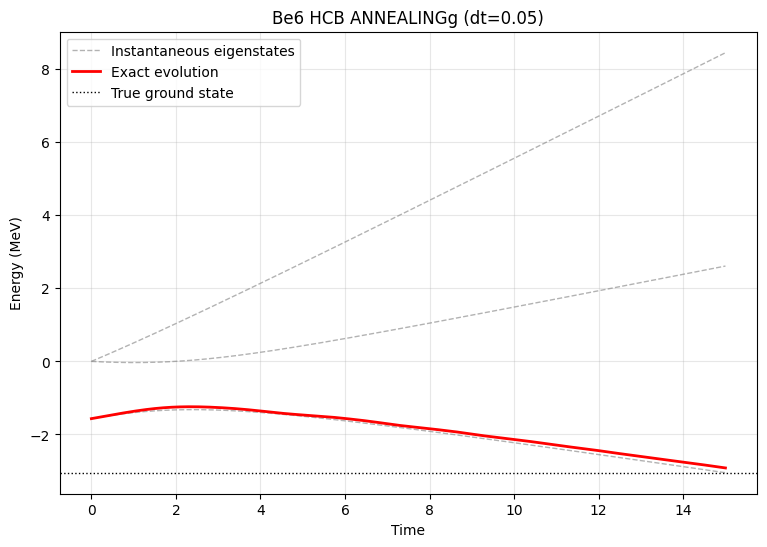

In [8]:
inst = exact["energies_instantaneous"]

plt.figure(figsize=(9, 6))
for i in range(inst.shape[1]):
    plt.plot(exact["time_points"], inst[:, i], "--", color="gray", lw=1, alpha=0.6,
             label="Instantaneous eigenstates" if i == 0 else None)
plt.plot(exact["time_points"], exact["energies_expected"], "r-", lw=2, label="Exact evolution")
plt.axhline(nuc.eig_val[0], color="k", lw=1, ls=":", label="True ground state")
plt.xlabel("Time"); plt.ylabel("Energy (MeV)")
plt.title(f"{nucleus_name} HCB ANNEALINGg (dt={dt})")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


## HCB ANNEALINGg - nearest-neighbor swap network

The direct-gate circuit above applies e.g. an `RXXYY` gate straight between whichever two qubits a hopping term connects, regardless of how far apart they are - not realistic on hardware with only nearest-neighbor connectivity. The swap network instead only ever applies 2-qubit gates between *adjacent* physical qubits, sweeping the logical-mode <-> physical-qubit mapping back and forth with SWAP gates so that every pair of modes becomes adjacent at some point during the sweep. This trades circuit depth for a hardware-realistic connectivity model.

Both are built from the exact same `nucleus.ops_1_body/ops_2_body/ops_hop` coefficients, so they should converge to the same physics as the step count grows.


In [9]:
nuc = Nucleus("Be6", shell="p", encoding="HCB")
protocol = AnnealingProtocol(nuc, ref_state=0, encoding="HCB")

steps, dt = 300, 0.05
direct = protocol.run(steps=steps, dt=dt, swap_network=False)
swap = protocol.run(steps=steps, dt=dt, swap_network=True)

print(f"Direct-gate fidelity:       {direct['fidelity']:.4f}")
print(f"Swap-network fidelity:      {swap['fidelity']:.4f}")
print(f"Direct-gate circuit depth:  {direct['circuit'].depth}")
print(f"Swap-network circuit depth: {swap['circuit'].depth}")


Direct-gate fidelity:       0.9827
Swap-network fidelity:      0.9802
Direct-gate circuit depth:  1202
Swap-network circuit depth: 2101


100%|██████████| 10/10 [00:06<00:00,  1.57it/s]


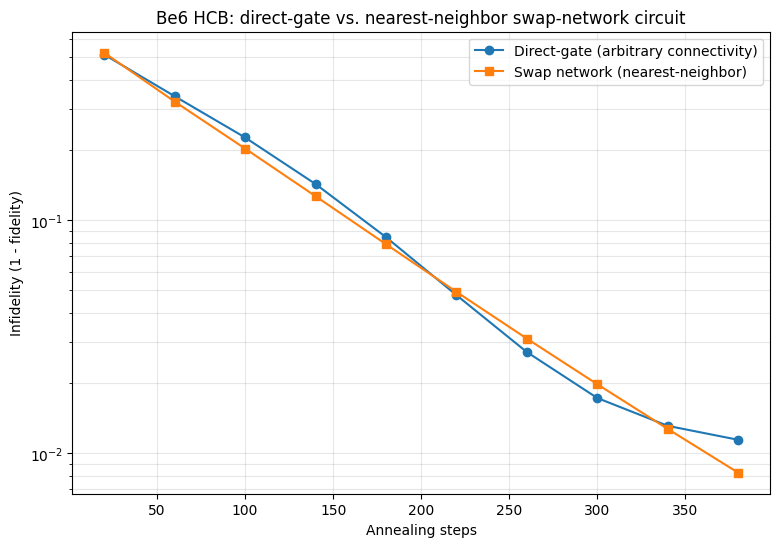

In [10]:
steps_list = list(range(20, 400, 40))
dt = 0.05

fid_direct, fid_swap = [], []
for steps in tqdm(steps_list):
    fid_direct.append(protocol.run(steps=steps, dt=dt, swap_network=False)["fidelity"])
    fid_swap.append(protocol.run(steps=steps, dt=dt, swap_network=True)["fidelity"])

plt.figure(figsize=(9, 6))
plt.plot(steps_list, 1 - np.array(fid_direct), "o-", label="Direct-gate (arbitrary connectivity)")
plt.plot(steps_list, 1 - np.array(fid_swap), "s-", label="Swap network (nearest-neighbor)")
plt.yscale("log")
plt.xlabel("Annealing steps"); plt.ylabel("Infidelity (1 - fidelity)")
plt.title("Be6 HCB: direct-gate vs. nearest-neighbor swap-network circuit")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.show()


## Summary

* Both encodings' target Hamiltonian, expressed as Pauli sums for the circuit, exactly reproduce `nucleus.H` once projected back onto the physical subspace - the circuit is ANNEALINGg under the *real* nuclear Hamiltonian, not an approximation of it.
* Fidelity to the true ground state increases toward 1 as the number of ANNEALINGg steps grows, for the fermionic circuit, the HCB direct-gate circuit, and the HCB nearest-neighbor swap-network circuit alike - the swap network pays for hardware-realistic connectivity with extra circuit depth, not with worse asymptotic convergence.
